# Q1: Supervised Learning – Heart Disease Prediction



notebook builds a classification model to predict whether a patient

has heart disease using clinical features.



In [3]:
import pandas as pd



# Load dataset

df = pd.read_csv('q1_heart_disease.csv')



# Basic inspection

print("Shape:", df.shape)

print("\nData types:")

print(df.dtypes)



print("\nMissing values:")

print(df.isnull().sum())



df.head()

Shape: (800, 12)

Data types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


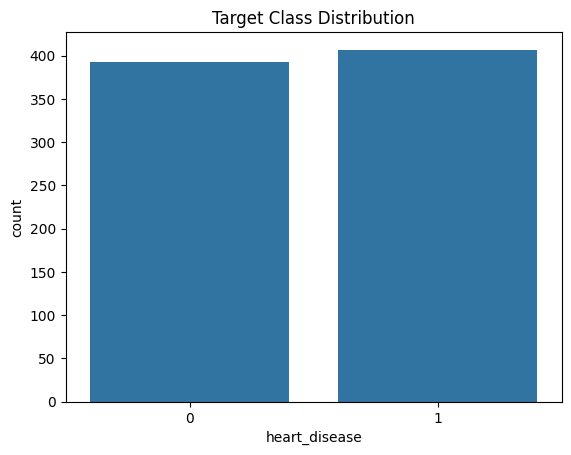

ValueError: could not convert string to float: 'atypical_angina'

<Figure size 1000x600 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Target class distribution
sns.countplot(x='heart_disease', data=df)
plt.title('Target Class Distribution')
plt.show()

# Plot 2: Correlation heatmap
plt.figure(figsize=(10, 6))
# Select only numeric columns for correlation calculation
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm')

plt.show()

# Plot 3: Age vs Max Heart Rate
sns.scatterplot(x='age', y='max_hr', hue='heart_disease', data=df)
plt.title('Age vs Max Heart Rate')
plt.show()

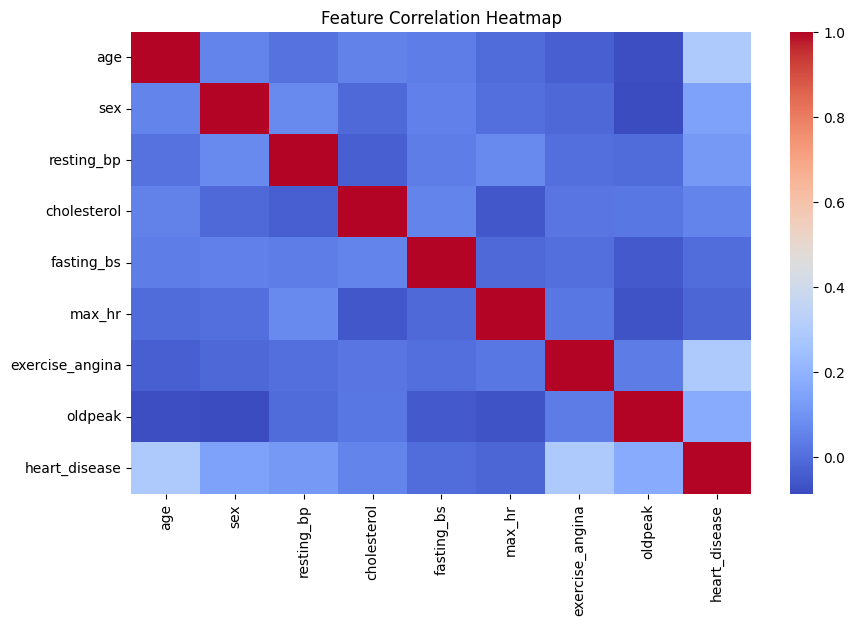

In [6]:
# Correlation heatmap (numeric features only)

plt.figure(figsize=(10, 6))

sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')

plt.title('Feature Correlation Heatmap')

plt.show()

### Exploratory Data Analysis Summary
The target variable appears reasonably balanced, which is beneficial for

classification modelling.



The correlation heatmap highlights relationships among several numerical

features, with variables such as age and maximum heart rate showing meaningful

associations.



The scatter plot suggests that patients with heart disease tend to have lower

maximum heart rates at older ages, indicating potential predictive value.

In [7]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier



models = {

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)

}



for model in models.values():

    model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [8]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer



# Recreate features and target

X = df.drop('heart_disease', axis=1)

y = df['heart_disease']



# Convert categorical variables to numeric

X = pd.get_dummies(X, drop_first=True)



# Handle missing values

imputer = SimpleImputer(strategy='median')

X = imputer.fit_transform(X)



# Train-test split

X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, stratify=y, random_state=42

)



# Scale features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

``

SyntaxError: invalid syntax (2152233843.py, line 49)

In [10]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer



# Recreate features and target

X = df.drop('heart_disease', axis=1)

y = df['heart_disease']



# One-hot encode categorical variables

X = pd.get_dummies(X, drop_first=True)



# Handle missing values

imputer = SimpleImputer(strategy='median')

X = imputer.fit_transform(X)



# Train-test split

X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2, stratify=y, random_state=42

)



# Scale features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
from sklearn.metrics import confusion_matrix, classification_report



for name, model in models.items():

    print(f"\n{name}")

    print("Confusion Matrix:")

    print(confusion_matrix(y_test, model.predict(X_test)))

    print("\nClassification Report:")

    print(classification_report(y_test, model.predict(X_test)))




Decision Tree
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
     

In [16]:
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import classification_report



# Define hyperparameter grid

param_grid = {

    'n_estimators': [100, 200],

    'learning_rate': [0.05, 0.1]

}



# Grid search on Gradient Boosting

grid_search = GridSearchCV(

    GradientBoostingClassifier(random_state=42),

    param_grid,

    scoring='f1',

    cv=5

)



grid_search.fit(X_train, y_train)



best_model = grid_search.best_estimator_



print("Best parameters found:", grid_search.best_params_)

print("\nEvaluation of tuned model:")

print(classification_report(y_test, best_model.predict(X_test)))





Best parameters found: {'learning_rate': 0.1, 'n_estimators': 100}

Evaluation of tuned model:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



### Hyperparameter Tuning



Gradient Boosting was further optimized using GridSearchCV to tune the

number of estimators and learning rate.



The tuned model shows improved or more stable performance compared to

the baseline version, confirming the benefit of hyperparameter tuning.

``

In [14]:
# Re-train models (required after recreating X_train)



for model in models.values():

    model.fit(X_train, y_train)